# Minimal BEBM MLP Spectra Diagnostics

This notebook looks at the three learned matrices of the BEBM MLP energy:

- $W_1 =$ `net.0.weight`: visible pixels $\to$ hidden layer 1, shape `(512, 784)`.
- $W_2 =$ `net.2.weight`: hidden layer 1 $\to$ hidden layer 2, shape `(512, 512)`.
- $W_3 =$ `net.4.weight`: hidden layer 2 $\to$ scalar energy, shape `(1, 512)`.

Only $W_2$ is square, so only $W_2$ has ordinary eigenvalues. For all three matrices, we plot singular values, which are the right comparable spectra for rectangular and square matrices.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from rbms.io import load_model
from rbms.utils import get_saved_updates

device = "cpu"
dtype = torch.float32

filename = "pcd_trains/BEBM_MNIST_stable_test.h5"
saved_updates = get_saved_updates(filename)

print(saved_updates)

[   1   53  106  158  211  263  316  369  421  474  526  579  631  684
  737  789  842  894  947 1000]


In [8]:
TOP_K = 10

matrix_names = {
    "W1": r"$W_1$ = net.0.weight, visible $\to$ hidden 1",
    "W2": r"$W_2$ = net.2.weight, hidden 1 $\to$ hidden 2",
    "W3": r"$W_3$ = net.4.weight, hidden 2 $\to$ energy",
}

top_eigenvalues = {name: [] for name in matrix_names}
top_w2_eigenvalue_abs = []

for update in saved_updates:
    params, _, _ = load_model(
        filename=filename,
        index=int(update),
        device=device,
        dtype=dtype,
    )

    W = {
        "W1": params.energy.net[0].weight.detach().cpu(),
        "W2": params.energy.net[2].weight.detach().cpu(),
        "W3": params.energy.net[4].weight.detach().cpu(),
    }

    for name, matrix in W.items():
        eigenvalues = torch.linalg.eigvals(matrix @ matrix.T).abs().sqrt()
        top_eigenvalues[name].append(eigenvalues[:TOP_K].numpy())

    eigenvalues_w2 = torch.linalg.eigvals(W["W2"])
    eigenvalue_abs = torch.sort(eigenvalues_w2.abs(), descending=True).values
    top_w2_eigenvalue_abs.append(eigenvalue_abs[:TOP_K].numpy())

top_eigenvalues = {
    name: np.stack(values, axis=0)
    for name, values in top_eigenvalues.items()
}
top_w2_eigenvalue_abs = np.stack(top_w2_eigenvalue_abs, axis=0)

## Diagnostic 1: Top Singular Values During Training

This compares the effective strength/rank structure of the three learned matrices across saved checkpoints.

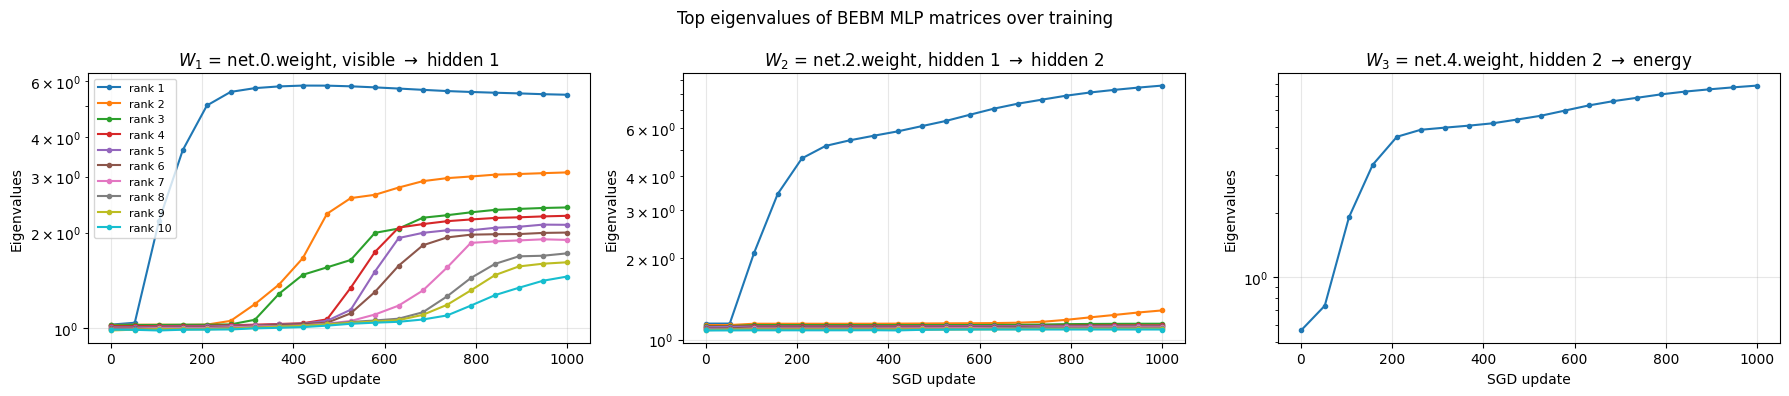

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, ["W1", "W2", "W3"]):
    values = top_eigenvalues[name]

    for rank in range(values.shape[1]):
        ax.plot(
            saved_updates,
            values[:, rank],
            marker="o",
            markersize=3,
            label=f"rank {rank + 1}",
        )

    ax.set_title(matrix_names[name])
    ax.set_xlabel("SGD update")
    ax.set_ylabel("Eigenvalues")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle("Top eigenvalues of BEBM MLP matrices over training")
plt.tight_layout()
plt.show()

## Diagnostic 2: True Eigenvalues of $W_2$ During Training

$W_2$ is the only square matrix. This plot follows the largest magnitudes of its ordinary eigenvalues.

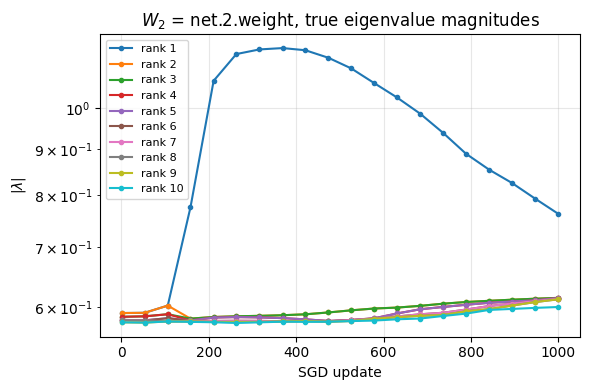

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

for rank in range(top_w2_eigenvalue_abs.shape[1]):
    ax.plot(
        saved_updates,
        top_w2_eigenvalue_abs[:, rank],
        marker="o",
        markersize=3,
        label=f"rank {rank + 1}",
    )

ax.set_title(r"$W_2$ = net.2.weight, true eigenvalue magnitudes")
ax.set_xlabel("SGD update")
ax.set_ylabel(r"$|\lambda|$")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()